# Image Segmentation with **scikit‑image**

This notebook demonstrates a simple pipeline for detecting bright objects in a microscopy image.

**Workflow**

| Step | Description |
|------|-------------|
| 0️⃣ | Import libraries |
| 1️⃣ | Load the image |
| 2️⃣ | (Optional) Contrast enhancement |
| 3️⃣ | Otsu thresholding |
| 4️⃣ | Mask clean‑up (small objects / holes) |
| 5️⃣ | Connected‑component labeling |
| 6️⃣ | Visualisation of each stage |
| 7️⃣ | Report the number of objects |

All required packages are part of the standard scientific Python stack. |


## Installation (optional)

If the environment does not already contain the required packages, run:

```bash
pip install -q scikit-image matplotlib
```

> **Tip:** Use a virtual environment to avoid permission warnings like the one shown in the output.  


In [1]:
!pip install -q scikit-image matplotlib


## 0. Import the necessary libraries


In [2]:
import numpy as np
from skimage import io, filters, morphology, measure, exposure, color
import matplotlib.pyplot as plt


## 1. Load the image

We read the sample file `blobs.tif`.  
If you have a different image, replace `image_path` with the appropriate path.


In [3]:
# Path to the example image (replace with your own path if needed)
image_path = "input_data/blobs.tif"

# Read the image – it may be 2‑D (grayscale) or 3‑D (RGB)
raw_image = io.imread(image_path)

# Convert to a normalized grayscale image in the range [0, 1]
if raw_image.ndim == 3:                     # RGB image → gray
    gray_image = color.rgb2gray(raw_image)
else:
    gray_image = raw_image.astype(float) / 255.0


## 2. Enhance contrast (optional)

Adaptive histogram equalisation (`exposure.equalize_adapthist`) stretches the intensity range, which often improves the separation between foreground and background before Otsu thresholding.


In [4]:
# Adaptive histogram equalisation stretches the intensity range
enhanced = exposure.equalize_adapthist(gray_image)


## 3. Compute an Otsu threshold

Otsu’s method automatically selects a global intensity threshold for bimodal histograms. The resulting binary mask (`binary_mask`) marks bright objects as **True**.


In [5]:
# Otsu's method works well for bimodal histograms
threshold_value = filters.threshold_otsu(enhanced)
binary_mask = enhanced > threshold_value


## 4. Clean the binary mask

* Remove isolated pixels (`remove_small_objects`, `min_size=20`).  
* Fill small holes (`remove_small_holes`, `area_threshold=20`).  

These operations reduce spurious detections before labeling.


In [6]:
# Remove small isolated pixels and fill small holes
cleaned = morphology.remove_small_objects(binary_mask, min_size=20)
cleaned = morphology.remove_small_holes(cleaned, area_threshold=20)


## 5. Label connected components

`measure.label` assigns a unique integer label to each connected region (8‑connectivity).  
`object_count` stores the total number of detected objects.


In [7]:
labeled_image = measure.label(cleaned, connectivity=2)
object_count = labeled_image.max()  # number of distinct labels


## 6. Visualise intermediate results

Three figures are displayed:

1. **Original gray image** – the raw data after conversion to grayscale.  
2. **Cleaned binary mask** – the thresholded image after small‑object / hole removal.  
3. **Labeled objects** – each detected object coloured uniquely (`color.label2rgb`).

The figures use a 5 × 5 inch canvas and have axes turned off for a cleaner look.


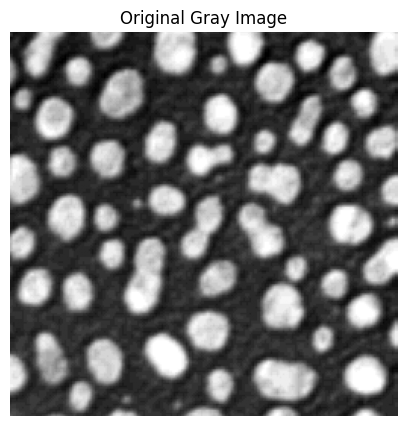

In [8]:
# Original gray image
fig1, ax1 = plt.subplots(figsize=(5, 5))
ax1.imshow(gray_image, cmap='gray')
ax1.set_title("Original Gray Image")
ax1.axis('off')
plt.show()


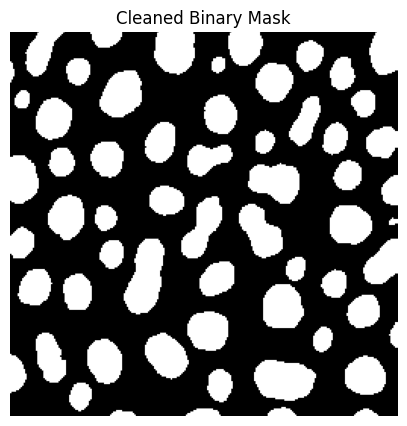

In [9]:
# Cleaned binary mask
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.imshow(cleaned, cmap='gray')
ax2.set_title("Cleaned Binary Mask")
ax2.axis('off')
plt.show()


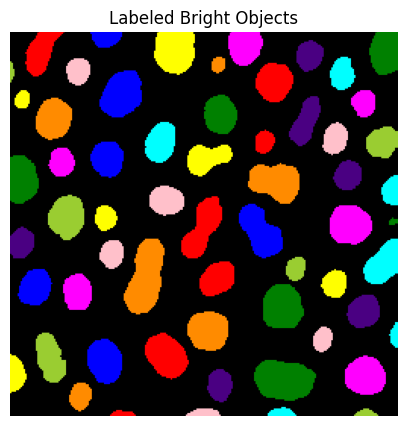

In [10]:
# Labeled objects with a random colormap
fig3, ax3 = plt.subplots(figsize=(5, 5))
ax3.imshow(color.label2rgb(labeled_image, bg_label=0))
ax3.set_title("Labeled Bright Objects")
ax3.axis('off')
plt.show()


## 7. Report the number of detected objects

The variable `object_count` holds the final count (61 for the provided `blobs.tif`).  
Feel free to change the image or the size thresholds to see how the count varies.


In [11]:
display("Number of bright objects")
print(object_count)


'Number of bright objects'

61
